In [3]:
import pandas as pd
import numpy as np
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

Part 2 Data preprocessing

In [4]:
import os
print(os.getcwd()) 
df = pd.read_csv('data/housing.csv')
df

f:\ML Internship\ML Week3-Task\notebook


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [5]:
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [6]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [7]:
#hanlding missing values in bedrook column
median_value = df['total_bedrooms'].median()
df['total_bedrooms'] = df['total_bedrooms'].fillna(median_value)

In [8]:
#Encoding
categorical_cols = df.select_dtypes(include=['object','category']).columns
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("\nData after Encoding:\n", df.head())


Data after Encoding:
    longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value  ocean_proximity  
0       322.0       126.0         8.3252            452600.0                3  
1      2401.0      1138.0         8.3014            358500.0                3  
2       496.0       177.0         7.2574            352100.0                3  
3       558.0       219.0         5.6431            341300.0                3  
4       565.0       259.0         3.8462            342200.0                3  


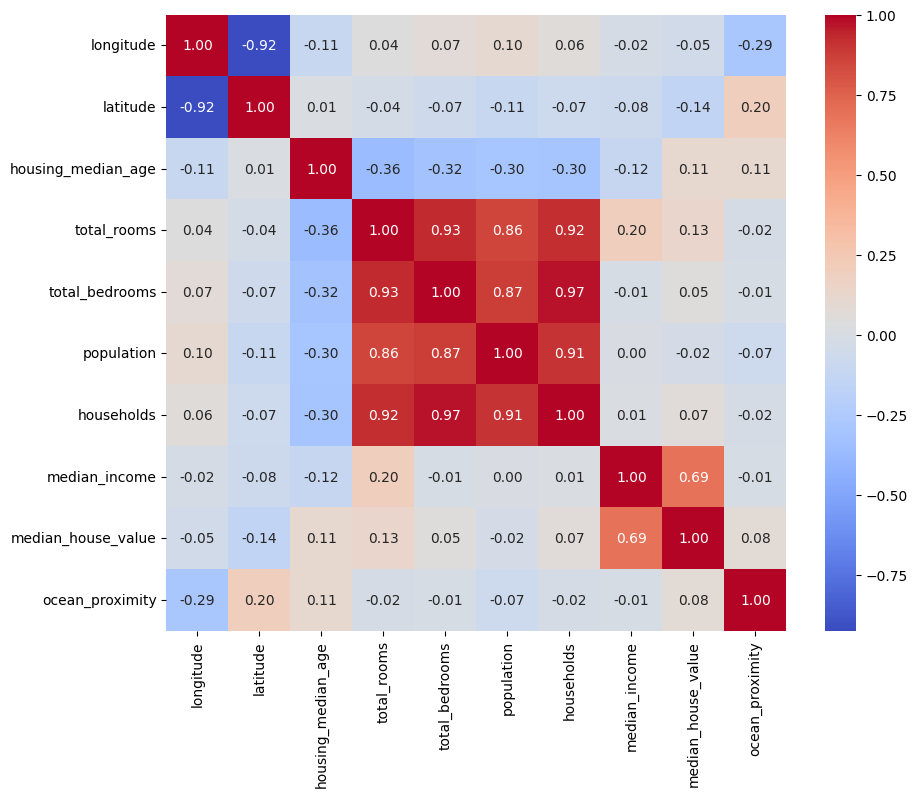

Dropping highly correlated features: ['total_bedrooms', 'households']


In [9]:
# finding co-relation in columns
corr_matrix = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(
corr_matrix,annot=True, cmap='coolwarm',fmt=".2f")
plt.show()
threshold = 0.9
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

print(f"Dropping highly correlated features: {to_drop}")
df = df.drop(columns=to_drop)

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

# Train / Test Split (80% training data, 20% testing data)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# 3. Data Normalization / Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Training data shape: (16512, 7)
Testing data shape: (4128, 7)


In [11]:
#part 3 model Training
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score
import numpy as np
import joblib
reg_model = LinearRegression()
reg_model.fit(X_train_scaled, y_train) 
reg_predictions = reg_model.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, reg_predictions))
print(f"Linear Regression RMSE (Error): {rmse:.2f}")
median_price = y.median()
y_train_class = (y_train > median_price).astype(int)
y_test_class = (y_test > median_price).astype(int)

clf_model = LogisticRegression()
clf_model.fit(X_train_scaled, y_train_class)
clf_predictions = clf_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test_class, clf_predictions)
print(f"Logistic Regression Accuracy: {accuracy * 100:.2f}%")

Linear Regression RMSE (Error): 72686.13
Logistic Regression Accuracy: 83.41%


In [12]:

joblib.dump(reg_model, 'linear_regression_model.pkl')
joblib.dump(clf_model, 'logistic_regression_model.pkl')
joblib.dump(scaler, 'data_scaler.pkl')

['data_scaler.pkl']

part 4 Model Evalation

Mean Absolute Error (MAE): $53,572.93
Mean Squared Error (MSE): 5,283,273,158.37

Accuracy Score: 83.41%
Precision: 0.84
Recall: 0.83



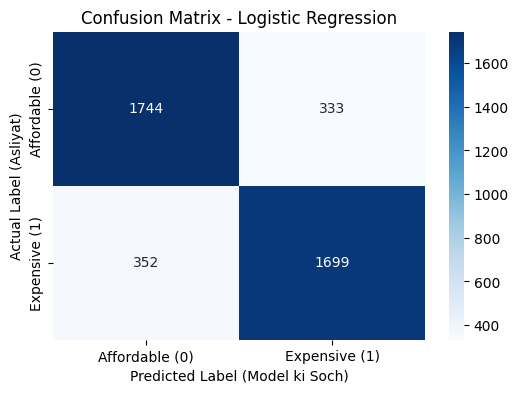

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
mae = mean_absolute_error(y_test, reg_predictions)
mse = mean_squared_error(y_test, reg_predictions)

print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Mean Squared Error (MSE): {mse:,.2f}\n")

accuracy = accuracy_score(y_test_class, clf_predictions)
precision = precision_score(y_test_class, clf_predictions)
recall = recall_score(y_test_class, clf_predictions)
conf_matrix = confusion_matrix(y_test_class, clf_predictions)

print(f"Accuracy Score: {accuracy * 100:.2f}%")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}\n")

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Affordable (0)', 'Expensive (1)'], 
            yticklabels=['Affordable (0)', 'Expensive (1)'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual Label (Asliyat)')
plt.xlabel('Predicted Label (Model ki Soch)')
plt.show()

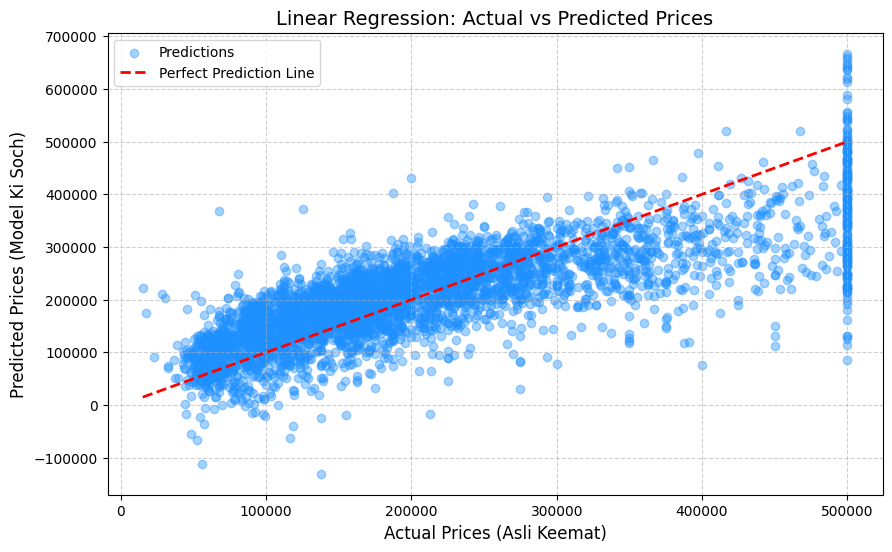

C:\Users\shushila\AppData\Local\Temp\ipykernel_14588\1705199997.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=metrics_names, y=metrics_values, palette='viridis')


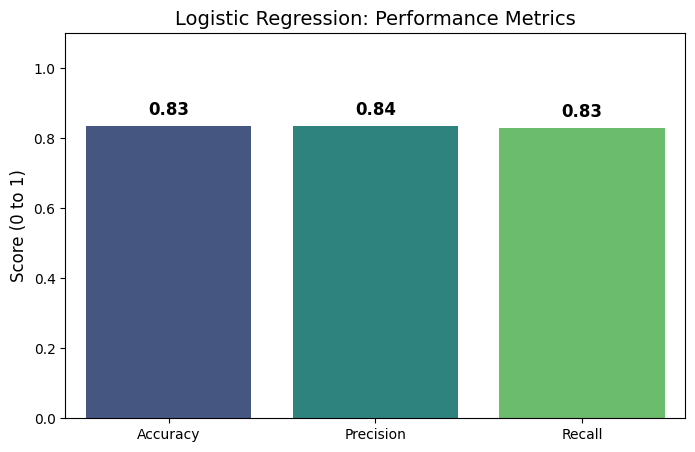

In [14]:

plt.figure(figsize=(10, 6))
plt.scatter(y_test, reg_predictions, alpha=0.4, color='dodgerblue', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         color='red', linestyle='--', linewidth=2, label='Perfect Prediction Line')

plt.title('Linear Regression: Actual vs Predicted Prices', fontsize=14)
plt.xlabel('Actual Prices (Asli Keemat)', fontsize=12)
plt.ylabel('Predicted Prices (Model Ki Soch)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

metrics_names = ['Accuracy', 'Precision', 'Recall']
metrics_values = [accuracy, precision, recall]

plt.figure(figsize=(8, 5))

ax = sns.barplot(x=metrics_names, y=metrics_values, palette='viridis')

plt.ylim(0, 1.1)
plt.title('Logistic Regression: Performance Metrics', fontsize=14)
plt.ylabel('Score (0 to 1)', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=12, fontweight='bold', color='black', xytext=(0, 5), 
                textcoords='offset points')
    

plt.show()

part 5 predicyion system deveploment

In [15]:

model = joblib.load('linear_regression_model.pkl')
scaler = joblib.load('data_scaler.pkl')

print("--- House Price Prediction System ---")
print("Please enter the following details:")


try:
    
    features = ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 
                'population', 'median_income', 'ocean_proximity']
    
    user_inputs = []
    for f in features:
        val = float(input(f"Enter {f}: "))
        user_inputs.append(val)
    

    input_array = np.array([user_inputs])
    

    input_scaled = scaler.transform(input_array)
    
  
    prediction = model.predict(input_scaled)
    
    print(f"\n--- Prediction ---")
    print(f"The estimated price of the house is: ${prediction[0]:,.2f}")

except Exception as e:
    print(f"Error: {e}. Please ensure you enter numerical values.")

--- House Price Prediction System ---
Please enter the following details:
Error: could not convert string to float: ''. Please ensure you enter numerical values.
